In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns

from enum import Enum

In [2]:
# Dictionary to hold our parsed data before converting to a DataFrame
# Format: { 'problem_name': { ('group', 'metric_name'): value } }
data_dict = {}
current_problem = None

# Define the prefixes we want to group by
prefixes = ['num_', 'dd_', 'ar_', 'ggraph_', 'solve_', 'tr_']

def read_into_data_dict(file):
    for line in file:
        line = line.strip()
                    
        if not line:
            continue
        
        # Set the current problem name for the row index
        if line.startswith("BEGINPROBLEM:"):
            current_problem = line.split(":", 1)[1]
            data_dict[current_problem] = {}
            continue
        
        if "=" in line and current_problem is not None:
            key, value_str = line.split("=", 1)
            
            # Parse lists or integers
            if value_str.startswith("[") and value_str.endswith("]"):
                inner_values = value_str[1:-1].strip()
                if inner_values:
                    parsed_value = [int(x) for x in inner_values.split(",")]
                else:
                    parsed_value = []
            else:
                parsed_value = int(value_str)
            
            # Determine 3-level grouping (Group, Subgroup, Metric)
            group = "other"
            subgroup = "base"
            metric = key
            
            for pref in prefixes:
                if key.startswith(pref):
                    group = pref
                    
                    # Further group specific dd_ metrics into sub-categories
                    if key.startswith("dd_thm_matches:"):
                        subgroup = "thm_matches"
                        metric = key.split(":", 1)[1] # Strip prefix for cleaner column names
                    elif key.startswith("dd_thm_duration:"):
                        subgroup = "thm_duration"
                        metric = key.split(":", 1)[1] # Strip prefix for cleaner column names
                    
                    break
            
            # Store data with a 3-part tuple key for the MultiIndex
            data_dict[current_problem][(group, subgroup, metric)] = parsed_value

In [3]:
file1 = open("imo/profiler.txt", "r")
read_into_data_dict(file1)
file2 = open("110-problems/profiler.txt", "r")
read_into_data_dict(file2)
file3 = open("mo-tg-225/profiler.txt", "r")
read_into_data_dict(file3)
file4 = open("jgex-231/profiler.txt", "r")
read_into_data_dict(file4)

In [ ]:
df = pd.DataFrame.from_dict(data_dict, orient='index')
print(df.shape)
    
# Convert the tuple columns into a 3-level pandas MultiIndex
if not df.empty:
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=['Group', 'Subgroup', 'Metric'])

In [16]:
df = df[df[("solve_", "base", "solve_success")] == 1.0]

In [18]:
imo_problem = df.loc[df.index.str.startswith("imo")]
problem_110 = df.loc[df.index.str.startswith("110")]
mo_tg_225_problem = df.loc[df.index.str.startswith("MO-TG-225")]
jgex_problem = df.loc[df.index.str.startswith("complete")]

In [19]:
N = len(df)
print(len(imo_problem), len(problem_110), len(mo_tg_225_problem), len(jgex_problem))
print(df.shape)
df.head()

27 108 14 55
(204, 130)


Group           num_                                solve_  \
Subgroup        base                                  base   
Metric   num_success num_params num_duration solve_success   
110-78           1.0        6.0         96.0           1.0   
110-73           1.0        7.0        113.0           1.0   
110-72           1.0        7.0         78.0           1.0   
110-71           1.0        6.0         92.0           1.0   
110-70           1.0        6.0         94.0           1.0   

Group                                                                     dd_  \
Subgroup                                                                 base   
Metric   solve_total_duration solve_iterations                    dd_duration   
110-78               439699.0              4.0  [8188, 52116, 132811, 194319]   
110-73               140740.0              2.0                 [10356, 91461]   
110-72                94825.0              3.0           [3950, 25766, 52077]   
110-71                84272.0              2.0                  [4922, 63670]   
110-70                47020.0              1.0                         [9313]   

Group                                                         ...  \
Subgroup                          thm_duration                ...   
Metric         dd_total_preds circle_coll_perp   circle_cong  ...   
110-78    [72, 177, 493, 671]     [6, 6, 8, 5]  [2, 2, 2, 1]  ...   
110-73             [266, 494]          [9, 11]        [2, 2]  ...   
110-72         [64, 126, 195]       [4, 6, 10]     [2, 1, 2]  ...   
110-71              [59, 141]         [36, 31]        [9, 8]  ...   
110-70                  [131]             [32]           [9]  ...   

Group                    ggraph_                                            \
Subgroup                    base                                             
Metric        ggraph_duration_dd    ggraph_duration_ar ggraph_num_preds_dd   
110-78    [927, 978, 1880, 1373]  [258, 252, 336, 364]     [14, 11, 7, 12]   
110-73              [2849, 1737]           [508, 1157]            [42, 12]   
110-72          [746, 1203, 500]        [166, 181, 82]         [13, 10, 1]   
110-71                [441, 658]            [285, 339]             [8, 10]   
110-70                    [1623]                [1372]                [35]   

Group                                                    tr_               \
Subgroup                                                base                
Metric   ggraph_num_preds_ar   ggraph_total_nodes tr_success tr_sol_depth   
110-78      [11, 11, 16, 17]  [93, 143, 299, 359]        1.0         10.0   
110-73              [14, 23]           [143, 267]        1.0          8.0   
110-72             [8, 6, 2]       [80, 143, 166]        1.0         11.0   
110-71               [20, 3]            [92, 116]        1.0          8.0   
110-70                  [79]                [235]        1.0          6.0   

Group                                       source  
Subgroup                                            
Metric   tr_sol_length tr_duration                  
110-78            29.0       821.0  Chou-Angle-110  
110-73            20.0       364.0  Chou-Angle-110  
110-72            33.0      1407.0  Chou-Angle-110  
110-71            25.0       354.0  Chou-Angle-110  
110-70            23.0       297.0  Chou-Angle-110  

[5 rows x 130 columns]

In [20]:
solve_total_duration = df[("solve_", "base", "solve_total_duration")]
dd_total_preds = df[("dd_", "base", "dd_total_preds")].map(lambda xs: xs[-1] if isinstance(xs, list) else xs)
ar_total_eqs = df[("ar_", "base", "ar_total_cols")].map(lambda xs: xs[-1] if isinstance(xs, list) else xs)
ggraph_total_nodes = df[("ggraph_", "base", "ggraph_total_nodes")].map(lambda xs: xs[-1] if isinstance(xs, list) else xs)
tr_sol_length = df[("tr_", "base", "tr_sol_length")]
tr_sol_depth = df[("tr_", "base", "tr_sol_depth")]
dd_duration = df[("dd_", "base", "dd_duration")].map(lambda xs: sum(xs) if isinstance(xs, list) else xs)
ar_duration = df[("ar_", "base", "ar_duration")].map(lambda xs: sum(xs) if isinstance(xs, list) else xs)
synthesis_duration = df[("ggraph_", "base", "ggraph_duration_dd")].map(lambda xs: sum(xs) if isinstance(xs, list) else xs) + df[("ggraph_", "base", "ggraph_duration_ar")].map(lambda xs: sum(xs) if isinstance(xs, list) else xs)

In [21]:
# add a "Source" column to the df based on the imo_problem, problem_110, mo_tg_225_problem and jgex_problem indices
df["source"] = "Other"
df.loc[problem_110.index, "source"] = "Chou-Angle-110"
df.loc[jgex_problem.index, "source"] = "JGEX-60"
df.loc[imo_problem.index, "source"] = "IMO-AG-30"
df.loc[mo_tg_225_problem.index, "source"] = "MO-TG-225-25"
assert (df["source"] == "Other").sum() == 0, "Some problems were not assigned a source"
# sort the df rows so that the "source" column is in the order of "Chou-Angle-110", "JGEX-60", "IMO-AG-30", "MO-TG-225-25", "Other"
df["source"] = pd.Categorical(df["source"], categories=["Chou-Angle-110", "JGEX-60", "IMO-AG-30", "MO-TG-225-25"], ordered=True)
df = df.sort_values("source")

In [22]:
# assemble a dataframe of the above 4 series, with the index as the problem name
df_summary = pd.DataFrame({
    "solve_total_duration": solve_total_duration,
    "dd_total_preds": dd_total_preds,
    "ar_total_cols": ar_total_eqs,
    "ggraph_total_nodes": ggraph_total_nodes,
    "tr_sol_length": tr_sol_length,
    "tr_sol_depth": tr_sol_depth,
    "source": df["source"]
})
df_summary.head()

,solve_total_duration,dd_total_preds,ar_total_cols,ggraph_total_nodes,tr_sol_length,tr_sol_depth,source
110-1,89301.0,226,16,178,17.0,7.0,Chou-Angle-110
110-10,71949.0,262,7,163,17.0,8.0,Chou-Angle-110
110-100,643983.0,1080,16,120,31.0,10.0,Chou-Angle-110
110-101,186397.0,411,14,205,15.0,7.0,Chou-Angle-110
110-102,32861.0,252,10,148,10.0,5.0,Chou-Angle-110


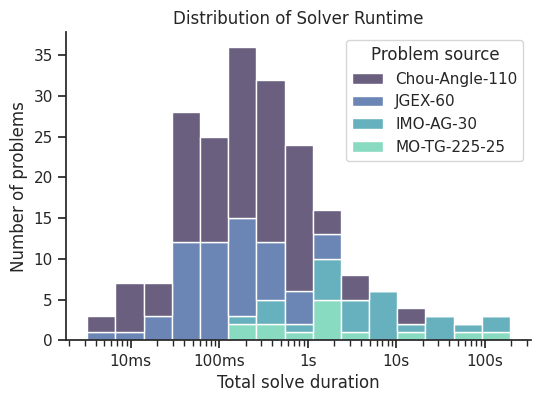

In [23]:
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)

sns.histplot(
    df_summary, 
    x="solve_total_duration", ax=ax, bins=15, log_scale=True, 
    hue="source", multiple="stack", palette="mako", 
)
ax.set_title("Distribution of Solver Runtime")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Number of problems")
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])
# rename the legend to say "Problem source"
ax.legend_.set_title("Problem source")

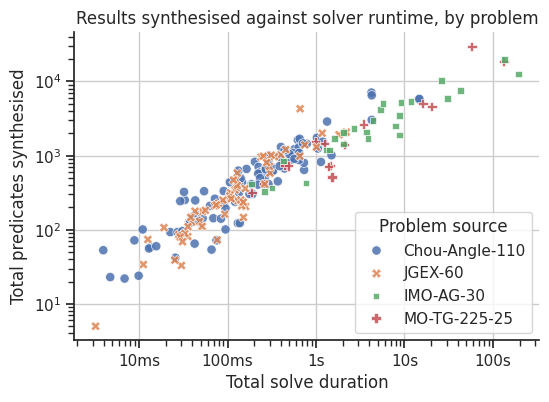

In [81]:
# Scatter plot of total predicates vs solve duration
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)

sns.scatterplot(
    df_summary,
    x="solve_total_duration", y="dd_total_preds", hue="source", style="source",
    ax=ax, alpha=0.85, s=45
)

ax.set_title("Results synthesised against solver runtime, by problem")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Total predicates synthesised")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])
# move the legend into the bottom_right
ax.legend(loc='lower right', title="Problem source")
ax.grid()

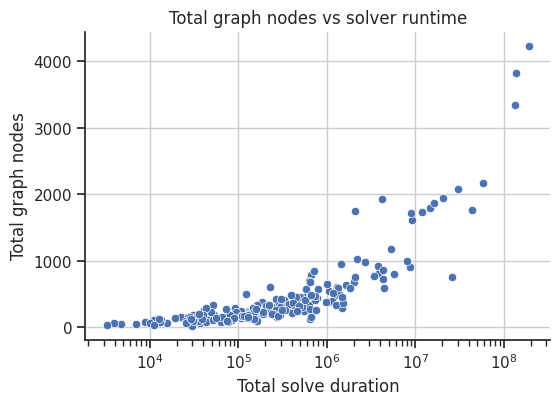

In [15]:
# Scatter plot of total graph nodes vs solve duration
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(y=ggraph_total_nodes, x=solve_total_duration, ax=ax)
ax.set_title("Total graph nodes vs solver runtime")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Total graph nodes")
ax.set_xscale('log')
ax.grid()

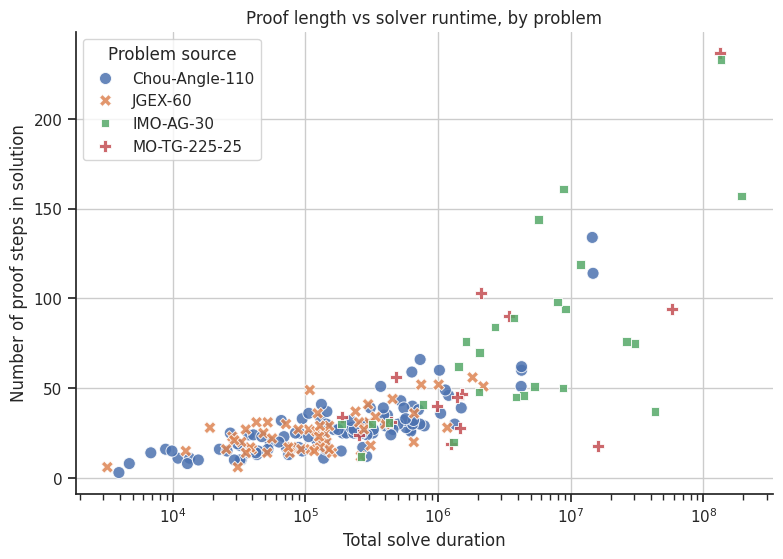

In [75]:
# Scatter plot of proof length vs solve duration
f, ax = plt.subplots(figsize=(9, 6))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(
    df_summary,
    x="solve_total_duration", y="tr_sol_length", hue="source", style="source",
    ax=ax, alpha=0.85, s=75
)
ax.set_title("Proof length vs solver runtime, by problem")
ax.set_xlabel("Total solve duration")
ax.set_ylabel("Number of proof steps in solution")
ax.set_xscale('log')
# ax.set_xticks([1e4, 1e5, 1e6, 1e7, 1e8])
# ax.set_xticklabels(['10ms', '100ms', '1s', '10s', '100s'])
ax.legend(title="Problem source")
ax.grid()

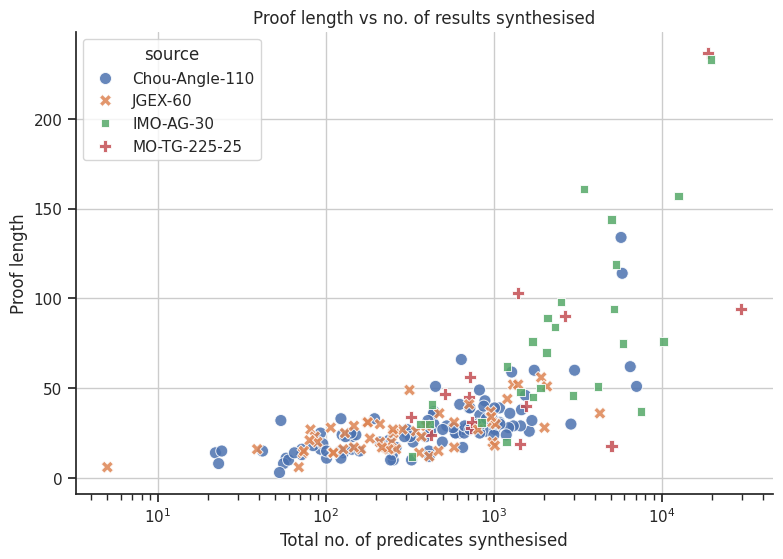

In [ ]:
# Scatter plot of proof length vs no. of results synthesised
f, ax = plt.subplots(figsize=(9, 6))
sns.set_theme(style="ticks")
sns.despine(f)
sns.scatterplot(
    df_summary,
    x="dd_total_preds", y="tr_sol_length", hue="source", style="source",
    ax=ax, alpha=0.85, s=75
)
ax.set_title("Proof length vs no. of results generated, by problem")
ax.set_xlabel("Total no. of predicates synthesised")
ax.set_ylabel("Proof length")
ax.set_xscale('log')
ax.grid()

/tmp/ipykernel_38474/3406200395.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")


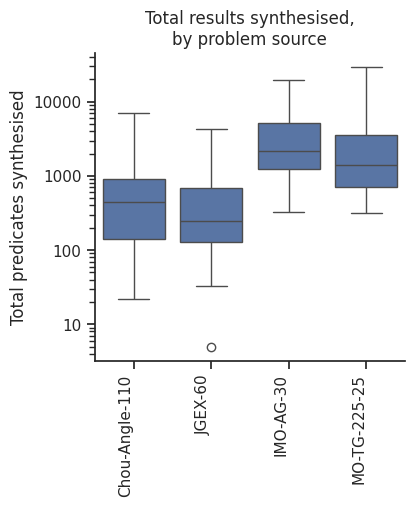

In [100]:
# Box plot 
f, ax = plt.subplots(figsize=(4, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.boxplot(
    df_summary, x="source", y="dd_total_preds", ax=ax, log_scale=True
)
ax.set_title("Total results synthesised,\nby problem source")
ax.set_ylabel("Total predicates synthesised")
# make the x-axis tick labels vertical
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
# remove the x-axis label
ax.set_xlabel("")
# make the y-axis tick labels normal numbers
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

/tmp/ipykernel_38474/2957415134.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")


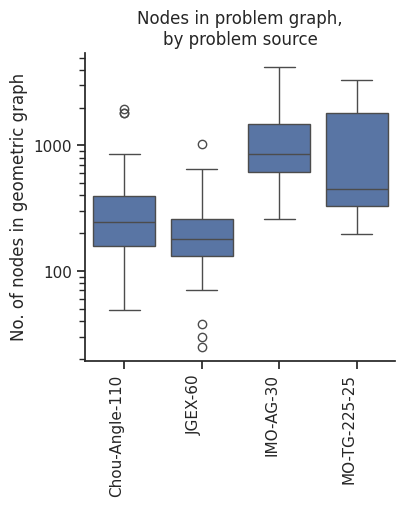

In [102]:
# Box plot 
f, ax = plt.subplots(figsize=(4, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.boxplot(
    df_summary, x="source", y="ggraph_total_nodes", ax=ax, log_scale=True
)
ax.set_title("Nodes in problem graph,\nby problem source")
ax.set_ylabel("No. of nodes in geometric graph")
# make the x-axis tick labels vertical
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
# remove the x-axis label
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

In [18]:
df["dd_", "thm_duration"]

/tmp/ipykernel_38474/1499160504.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df["dd_", "thm_duration"]


Metric,circle_coll_perp,circle_cong,circle_eqangle_perp,circle_perp_eqangle,coll_coll_ncoll_diffside_p_diffside_p_eqratio_cyclic,coll_coll_ncoll_diffside_p_diffside_p_eqratio_simtri,coll_coll_ncoll_para_cong_cong_para,coll_coll_ncoll_para_eqratio_para,coll_coll_ncoll_sameside_p_sameside_p_eqratio_cyclic,cong_cong_cong_ncoll_contri,...,para_coll_coll_ncoll_simtri,para_coll_ncoll_eqangle,para_diff_coll,para_para_eqangle_ncoll_simtri,para_para_ncoll_cong,para_para_para_ncoll_simtri,perp_midp_cong,perp_perp_diff_cyclic,perp_perp_diff_perp,perp_perp_ncoll_para
110-78,"[6, 6, 8, 5]","[2, 2, 2, 1]","[1, 1, 1, 1]","[1, 1, 2, 1]","[252, 309, 282, 275]","[230, 243, 272, 293, 303, 313, 366, 381]","[1575, 1847, 1716, 1721]","[1557, 1806, 1743, 1710]","[230, 271, 266, 253]","[79, 383, 198, 539]",...,"[6, 7, 81, 94]","[3, 3, 80, 88]","[3, 3, 12, 12]","[3, 3, 327, 427]","[2, 3, 65, 75]","[3, 3, 265, 348]","[70, 69, 137, 160]","[408, 206, 566, 445]","[411, 338, 831, 910]","[988, 763, 2731, 3129]"
110-73,"[9, 11]","[2, 2]","[2, 2]","[2, 2]","[171, 279]","[158, 157, 317, 298]","[561, 2466]","[543, 2144]","[148, 250]","[5, 8]",...,"[43, 11]","[29, 4]","[76, 4]","[149, 4]","[53, 4]","[121, 3]","[119, 95]","[550, 353]","[710, 698]","[2003, 1989]"
110-72,"[4, 6, 10]","[2, 1, 2]","[1, 1, 2]","[1, 1, 1]","[144, 162, 216]","[146, 139, 149, 152, 197, 203]","[485, 533, 648]","[486, 521, 644]","[133, 146, 180]","[8, 4, 12]",...,"[4, 11, 8]","[2, 4, 4]","[2, 4, 9]","[2, 5, 4]","[2, 4, 4]","[2, 3, 4]","[62, 80, 84]","[336, 272, 243]","[313, 440, 389]","[746, 935, 836]"
110-71,"[36, 31]","[9, 8]","[12, 983]","[19, 19]","[140, 140]","[151, 135, 170, 149]","[492, 493]","[478, 489]","[160, 158]","[378, 368]",...,"[34, 55]","[166, 42]","[6, 8]","[87, 105]","[27, 29]","[71, 86]","[61, 72]","[334, 222]","[323, 365]","[743, 831]"
110-70,[32],[9],[12],[18],[265],"[296, 260]",[1193],[1178],[321],[1139],...,[3],[2],[2],[3],[2],[1],[1],[2],[1],[2]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MO-TG-225-5,"[18, 13, 12]","[2, 3, 3]","[2, 4, 3]","[2, 3, 2]","[678, 439, 427]","[773, 657, 771, 647, 1105, 917]","[3797, 3915, 3097]","[3934, 4073, 3062]","[962, 522, 385]","[20, 11, 20]",...,"[41, 14, 12]","[6, 5, 7]","[5, 5, 12]","[5, 6, 7]","[6, 6, 6]","[7, 5, 6]","[212, 195, 242]","[1898, 692, 595]","[1210, 1159, 1009]","[2943, 2793, 2441]"
MO-TG-225-4,"[12, 9]","[1, 2]","[1, 2]","[1, 1]","[4069, 3957]","[5199, 4396, 4794, 4747]","[29233, 27626]","[26149, 25551]","[4243, 4120]","[496, 2231]",...,"[235, 1650]","[405, 4245]","[9, 116]","[60, 819]","[32, 778]","[53, 725]","[389, 228]","[414, 570]","[1384, 1347]","[7828, 7274]"
MO-TG-225-3,"[21, 10, 9]","[3, 3, 3]","[3, 2, 2]","[3, 2, 2]","[2441, 1807, 1652]","[2541, 2582, 1892, 1869, 2284, 2166]","[15860, 14144, 12225]","[17274, 15296, 15249]","[2042, 1980, 1985]","[757, 712, 7596]",...,"[3, 2218, 875]","[2, 6351, 905]","[2, 88, 69]","[3, 2855, 8099]","[2, 2234, 545]","[2, 3281, 7089]","[3, 7, 5]","[2, 3, 3]","[2, 3, 3]","[3, 3, 3]"
MO-TG-225-10,"[73, 31, 79, 83]","[12, 10, 28, 29]","[25, 2475, 14316, 23102]","[24, 25, 58, 860]","[3106, 3042, 2678, 16842]","[3447, 3601, 4304, 3882, 44675, 7622, 23919, 5...","[28561, 29568, 22879, 24307]","[26517, 27031, 22950, 22745]","[3743, 3607, 3770, 3411]","[933, 1316, 2145, 2132]",...,"[5, 463, 257, 289]","[2, 650, 258, 292]","[2, 29, 23, 105]","[3, 335, 1373, 1601]","[2, 159, 175, 220]","[2, 317, 979, 1308]","[365, 324, 386, 399]","[1010, 1161, 1080, 1140]","[2418, 2425, 2539, 2550]","[9350, 11713, 11975, 12161]"


/tmp/ipykernel_7218/4256969994.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_thm_duration_per_problem = df[("dd_", "thm_duration")].map(lambda xs : sum(xs) if isinstance(xs, list) else xs)


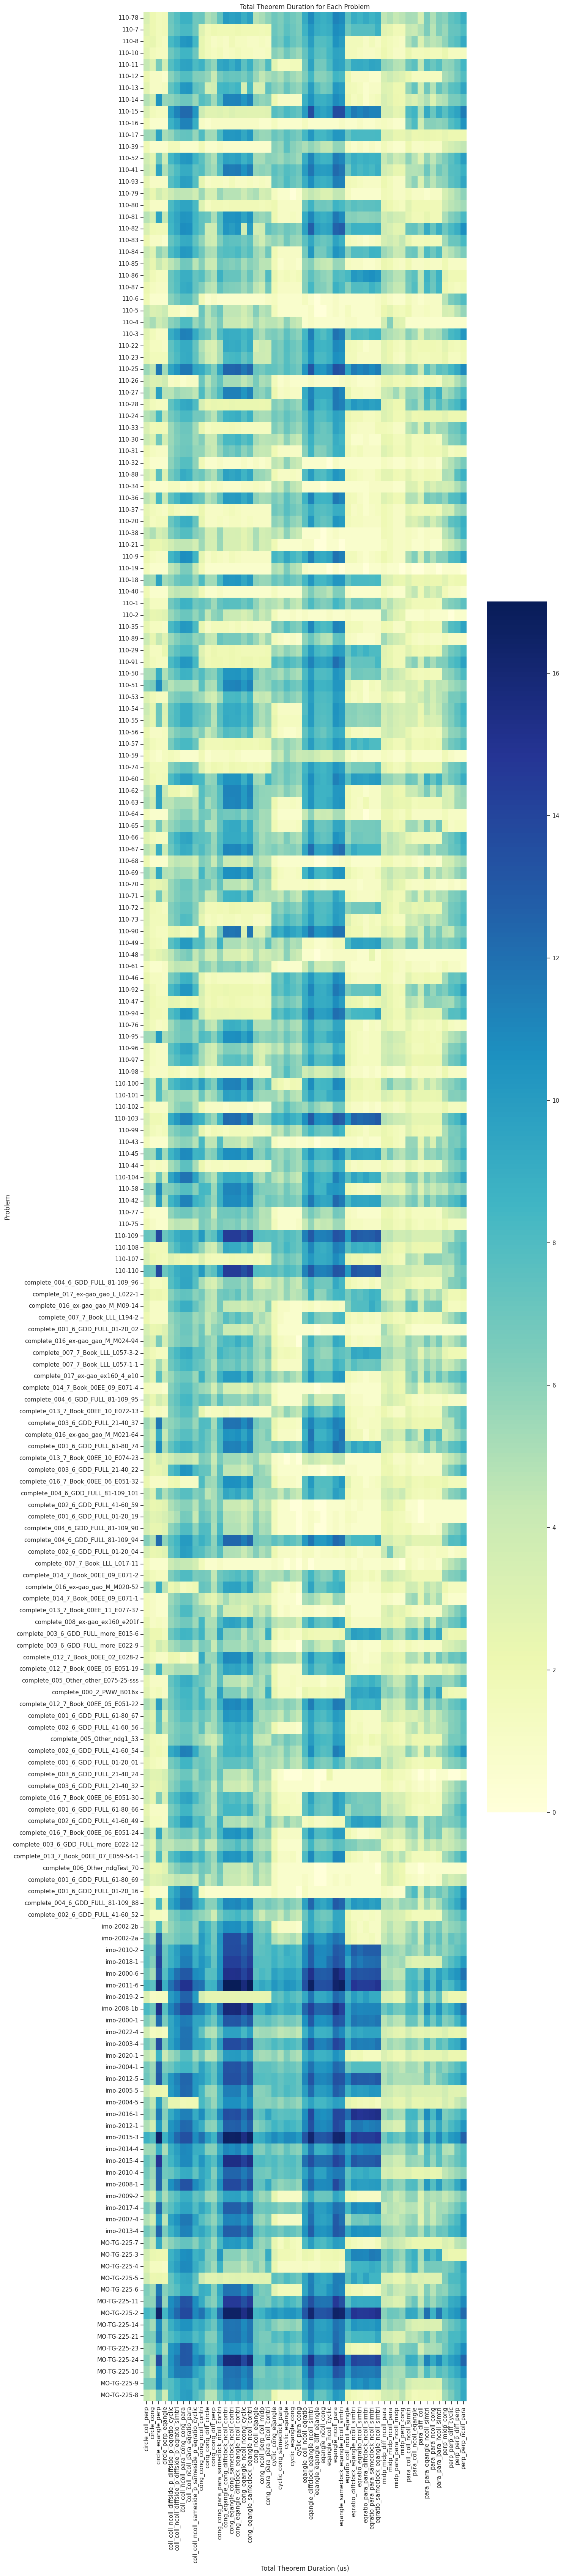

In [24]:
# Create another dataframe where every entry is equal to the sum of the elements in the list in df["dd_", "thm_duration"]
df_thm_duration_per_problem = df[("dd_", "thm_duration")].map(lambda xs : sum(xs) if isinstance(xs, list) else xs)

# Plot a heatmap of df_thm_duration_per_problem, with the index as the y-axis and the values as the x-axis
plt.figure(figsize=(15,N // 3))
sns.heatmap(np.log(df_thm_duration_per_problem + 1), annot=False, fmt=".1f", cmap="YlGnBu")
plt.xlabel("Total Theorem Duration (us)")
plt.ylabel("Problem")
plt.title("Total Theorem Duration for Each Problem")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [66]:
df_thm_duration_per_problem.head()

Metric,circle_coll_perp,circle_cong,circle_eqangle_perp,circle_perp_eqangle,coll_coll_ncoll_diffside_p_diffside_p_eqratio_cyclic,coll_coll_ncoll_diffside_p_diffside_p_eqratio_simtri,coll_coll_ncoll_para_cong_cong_para,coll_coll_ncoll_para_eqratio_para,coll_coll_ncoll_sameside_p_sameside_p_eqratio_cyclic,cong_cong_cong_ncoll_contri,...,para_coll_coll_ncoll_simtri,para_coll_ncoll_eqangle,para_diff_coll,para_para_eqangle_ncoll_simtri,para_para_ncoll_cong,para_para_para_ncoll_simtri,perp_midp_cong,perp_perp_diff_cyclic,perp_perp_diff_perp,perp_perp_ncoll_para
110-78,25,7,4,5,1118,2401,6859,6816,1020,1199,...,188,174,30,760,145,619,436,1625,2490,7611
110-7,17,7,4,5,962,2009,3726,3685,1007,18,...,76,59,133,652,105,566,280,1394,1465,3248
110-8,11,10,4,3,3786,7798,29140,34145,4500,11,...,131,404,22,155,93,130,358,1540,2469,10026
110-10,14,4,3,3,1058,2113,5049,4952,1134,11,...,10,4,4,5,4,4,9,3,3,3
110-11,74,20,741,38,2532,5943,14900,15939,3393,6227,...,1024,1971,77,2892,1220,2495,329,397,1120,4905


In [72]:
# normalise df_thm_duration_per_problem across each row 
df_thm_proportion_per_problem = df_thm_duration_per_problem / df_thm_duration_per_problem.sum(axis=1).values.reshape(-1, 1)
df_thm_proportion_per_problem.head()

Metric,circle_coll_perp,circle_cong,circle_eqangle_perp,circle_perp_eqangle,coll_coll_ncoll_diffside_p_diffside_p_eqratio_cyclic,coll_coll_ncoll_diffside_p_diffside_p_eqratio_simtri,coll_coll_ncoll_para_cong_cong_para,coll_coll_ncoll_para_eqratio_para,coll_coll_ncoll_sameside_p_sameside_p_eqratio_cyclic,cong_cong_cong_ncoll_contri,...,para_coll_coll_ncoll_simtri,para_coll_ncoll_eqangle,para_diff_coll,para_para_eqangle_ncoll_simtri,para_para_ncoll_cong,para_para_para_ncoll_simtri,perp_midp_cong,perp_perp_diff_cyclic,perp_perp_diff_perp,perp_perp_ncoll_para
110-78,0.000065,0.000018,0.000010,0.000013,0.002890,0.006207,0.017731,0.017620,0.002637,0.003100,...,0.000486,0.000450,0.000078,0.001965,0.000375,0.001600,0.001127,0.004201,0.006437,0.019675
110-7,0.000091,0.000038,0.000022,0.000027,0.005178,0.010813,0.020054,0.019834,0.005420,0.000097,...,0.000409,0.000318,0.000716,0.003509,0.000565,0.003046,0.001507,0.007503,0.007885,0.017482
110-8,0.000057,0.000051,0.000021,0.000015,0.019450,0.040061,0.149703,0.175416,0.023118,0.000057,...,0.000673,0.002075,0.000113,0.000796,0.000478,0.000668,0.001839,0.007912,0.012684,0.051507
110-10,0.000220,0.000063,0.000047,0.000047,0.016596,0.033145,0.079199,0.077677,0.017788,0.000173,...,0.000157,0.000063,0.000063,0.000078,0.000063,0.000063,0.000141,0.000047,0.000047,0.000047
110-11,0.000303,0.000082,0.003037,0.000156,0.010379,0.024360,0.061075,0.065334,0.013908,0.025524,...,0.004197,0.008079,0.000316,0.011854,0.005001,0.010227,0.001349,0.001627,0.004591,0.020106


In [73]:
df_thm_proportion_avg = df_thm_proportion_per_problem.mean()
df_thm_proportion_avg.sort_values()

Metric
para_diff_coll                                          0.000213
midp_perp_cong                                          0.000268
midp_para_para_ncoll_midp                               0.000323
circle_cong                                             0.000436
circle_perp_eqangle                                     0.000659
para_para_ncoll_cong                                    0.000985
midp_midp_diff_ncoll_para                               0.000992
circle_coll_perp                                        0.001082
midp_midp_ncoll_para                                    0.001094
para_coll_coll_ncoll_simtri                             0.001509
perp_midp_cong                                          0.001942
para_coll_ncoll_eqangle                                 0.002184
eqratio_coll_ncoll_eqangle                              0.002395
cyclic_para_cong                                        0.002485
cyclic_cong_sameclock_para                              0.002521
cong_ncoll_perp_co

In [61]:
df_thm_matches_sum = df[("dd_", "thm_matches")].map(lambda xs : sum(xs) if isinstance(xs, list) else xs).sum()
df_thm_matches_sum.sort_values()

/tmp/ipykernel_7218/4280302156.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  df_thm_matches_sum = df[("dd_", "thm_matches")].map(lambda xs : sum(xs) if isinstance(xs, list) else xs).sum()


Metric
eqangle_ncoll_para                                          0
perp_perp_ncoll_para                                        0
cyclic_cong_sameclock_para                                  4
coll_coll_ncoll_para_cong_cong_para                         8
coll_coll_ncoll_para_eqratio_para                           8
coll_coll_ncoll_diffside_p_diffside_p_eqratio_simtri       16
midp_para_para_ncoll_midp                                  16
circle_coll_perp                                           20
cong_ncoll_perp_coll_midp                                  30
eqratio_coll_ncoll_eqangle                                 40
coll_coll_ncoll_diffside_p_diffside_p_eqratio_cyclic       56
circle_eqangle_perp                                        72
cyclic_cong_eqangle                                        73
midp_perp_cong                                             78
cyclic_eqangle_cong                                       101
eqangle_eqangle_diff_eqangle                              106
c

In [125]:
# join df_thm_proportion_avg and df_thm_matches_sum into a single dataframe
df_thms = pd.DataFrame({
    "thm_proportion_avg": df_thm_proportion_avg,
    "thm_matches_sum": df_thm_matches_sum
})
df_thms["thm_first_match"] = df_thms.index.map(lambda idx: idx.split("_")[0])
df_thms["thm_postcondition"] = df_thms.index.map(lambda idx: idx.split("_")[-1])

In [126]:
df_thms["thm_avg_per_match"] = df_thms["thm_proportion_avg"] / df_thms["thm_matches_sum"]

In [127]:
# drop eqangle_ncoll_para and perp_perp_ncoll_para from df_thms
df_thms = df_thms.drop(["eqangle_ncoll_para", "perp_perp_ncoll_para"], errors="ignore")

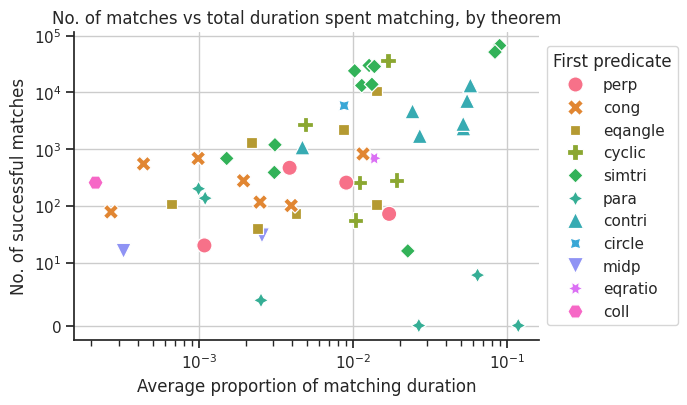

In [89]:
# Scatter plot of df_thm_matches_sum (y-axis) against df_thm_duration_sum (x-axis)
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
# sns.scatterplot(x=df_thm_duration_sum[outlier], y=df_thm_matches_sum[outlier], ax=ax, color='red')

ax.set_title("No. of matches vs total duration spent matching, by theorem")
ax.set_xlabel("Average proportion of matching duration")
ax.set_ylabel("No. of successful matches")
ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=10)
ax.grid()

sns.scatterplot(
    data=df_thms, 
    x="thm_proportion_avg", y="thm_matches_sum", hue="thm_postcondition", style="thm_postcondition",
    ax=ax, s=120
)
# ensure the legend is outside the plot area
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="First predicate")

/tmp/ipykernel_7218/2722748333.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


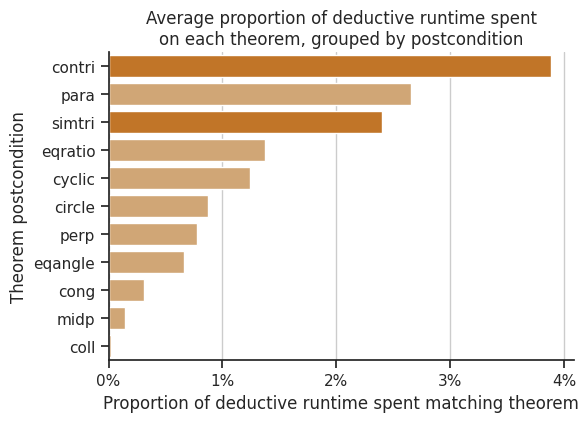

In [140]:
# bar plot of df["thm_proportion_avg"] by df["thm_postcondition"]
df_thms_by_postcondition = df_thms.groupby("thm_postcondition")["thm_proportion_avg"].mean().sort_values(ascending=False)
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
clrs = [(219/256, 117/256, 15/256) if x in ['contri', 'simtri'] else (224/256, 168/256, 103/256) for x in df_thms_by_postcondition.index]
sns.barplot(
    data=df_thms_by_postcondition, ax=ax, errorbar=None,
    orient="h", 
    palette=clrs
)
ax.set_title("Average proportion of deductive runtime spent\non each theorem, grouped by postcondition")
ax.set_ylabel("Theorem postcondition")
ax.set_xlabel("Proportion of deductive runtime spent matching theorem")
ax.set_xticks([0, 0.01, 0.02, 0.03, 0.04])
ax.set_xticklabels(['0%', '1%', '2%', '3%', '4%'])
# show grid
ax.grid(axis='x')

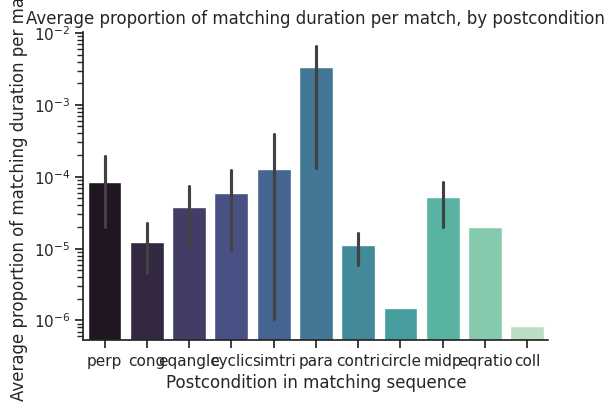

In [90]:
# bar plot of df["thm_avg_per_match"] by df["thm_first_match"]
f, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks")
sns.despine(f)
sns.barplot(
    data=df_thms, 
    x="thm_postcondition", y="thm_avg_per_match", hue="thm_postcondition", dodge=False,
    ax=ax, palette="mako"
)
ax.set_title("Average proportion of matching duration per match, by postcondition")
ax.set_xlabel("Postcondition in matching sequence")
ax.set_ylabel("Average proportion of matching duration per match")
ax.set_yscale('log')

In [39]:
df_durations = pd.DataFrame({
    "dd_duration": dd_duration,
    "ar_duration": ar_duration,
    "synthesis_duration": synthesis_duration,
    "total_duration": solve_total_duration,
    "source": df["source"]
})
df_durations = df_durations.sort_values("total_duration", ascending=False)

In [40]:
df_durations

,dd_duration,ar_duration,synthesis_duration,total_duration,source
imo-2011-6,178966132,14390255,140605,193499781.0,IMO-AG-30
imo-2015-3,129177178,6317865,131188,135630400.0,IMO-AG-30
MO-TG-225-2,130132911,2770456,112989,133018590.0,MO-TG-225-25
MO-TG-225-24,55006136,2708808,121548,57840376.0,MO-TG-225-25
imo-2008-1b,48364596,3724526,56808,52151373.0,IMO-AG-30
...,...,...,...,...,...
110-48,3769,3860,948,8855.0,Chou-Angle-110
110-21,2094,4043,442,6855.0,Chou-Angle-110
110-40,3285,764,347,4718.0,Chou-Angle-110
110-59,1310,1720,698,3939.0,Chou-Angle-110


In [41]:
df_durations["dd_fraction"] = df_durations["dd_duration"] / (df_durations["dd_duration"] + df_durations["ar_duration"])
df_durations["total_duration_magnitude"] = df_durations["total_duration"].map(lambda x: np.floor(np.log10(x)) if x > 0 else 0)

/tmp/ipykernel_7218/3062556531.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
/tmp/ipykernel_7218/3062556531.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


[Text(0, 0, '>100s'),
 Text(0, 1, '10s – 100s'),
 Text(0, 2, '1s – 10s'),
 Text(0, 3, '100ms – 1s'),
 Text(0, 4, '10ms – 100ms'),
 Text(0, 5, '<10ms')]

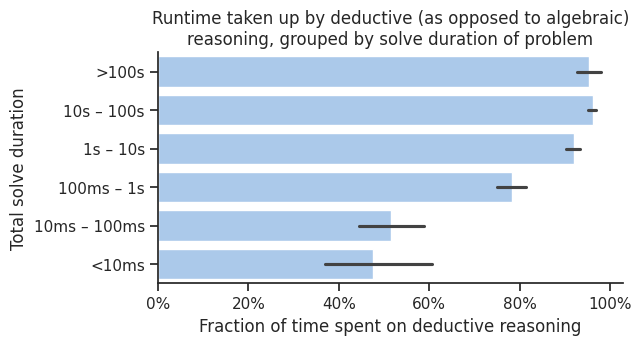

In [56]:
f, ax = plt.subplots(figsize=(6, 3))
sns.set_theme(style="ticks")
sns.despine(f)

# horizontal bar plot of dd_fraction, grouped by total_duration_magnitude
sns.barplot(
    data=df_durations, y="total_duration_magnitude", x="dd_fraction", ax=ax, orient='h', 
    order=df_durations["total_duration_magnitude"], palette="pastel", hue=True, legend=False
)
ax.set_title("Runtime taken up by deductive (as opposed to algebraic)\nreasoning, grouped by solve duration of problem")
ax.set_xlabel("Fraction of time spent on deductive reasoning")
ax.set_ylabel("Total solve duration")
ax.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
ax.set_yticklabels([
    ">100s", "10s – 100s", "1s – 10s", "100ms – 1s", "10ms – 100ms", "<10ms"
])

In [111]:
(solve_total_duration > 1e7).sum() / solve_total_duration.shape[0]

np.float64(0.057692307692307696)

In [10]:
df_summary.to_csv("profiler_summary.csv")